point cloud data is stored as a 2D matrix  
each row has 3 values i.e. the x, y, z value for a point

Project has to be submitted to github in the private folder assigned to you.  
Readme file should have the numerical values as described in each task.  
Create a folder to store the images as described in the tasks.

Try to create commits and version for each task.

In [17]:
import matplotlib
import numpy as np
from pathlib import Path
from scipy.spatial import KDTree
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [18]:
# utility functions
def show_cloud(points_plt, title=None):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection='3d')
    ax.scatter(points_plt[:,0], points_plt[:,1], points_plt[:,2], s=0.05)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    if title:
        ax.set_title(title)
    plt.show()

def show_scatter(x, y, title=None):
    plt.scatter(x, y)
    if title:
        plt.title(title)
    plt.show()

def get_ground_level(pcd, bins=100):
    z_values = pcd[:, 2]
    counts, bin_edges = np.histogram(z_values, bins=bins)
    ground_bin = np.argmax(counts)
    ground_level = (bin_edges[ground_bin] + bin_edges[ground_bin + 1]) / 2
    return ground_level

def plot_ground_histogram(pcd, dataset_name, bins=100):
    z_values = pcd[:, 2]
    counts, bin_edges = np.histogram(z_values, bins=bins)
    ground_bin = np.argmax(counts)
    ground_level = (bin_edges[ground_bin] + bin_edges[ground_bin + 1]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    Path('images').mkdir(exist_ok=True)

    plt.figure(figsize=(9, 5))
    plt.bar(bin_edges[:-1], counts, width=bin_width, align='edge', color='steelblue', edgecolor='white')
    plt.axvline(ground_level, color='crimson', linestyle='--', linewidth=2, label=f'ground level = {ground_level:.3f}')
    plt.title(f'{dataset_name}: z-height histogram')
    plt.xlabel('z value')
    plt.ylabel('number of points')
    plt.legend()
    plt.tight_layout()
    plt.savefig(Path('images') / f'{dataset_name}_ground_histogram.png', dpi=200)
    plt.show()

    return ground_level

In [19]:
# read files containing point cloud data
datasets = {
    'dataset1': np.load('dataset1.npy'),
    'dataset2': np.load('dataset2.npy'),
}

# Keep dataset1 selected for the starter cells below.
pcd = datasets['dataset1']

{name: data.shape for name, data in datasets.items()}

{'dataset1': (72067, 3), 'dataset2': (84588, 3)}

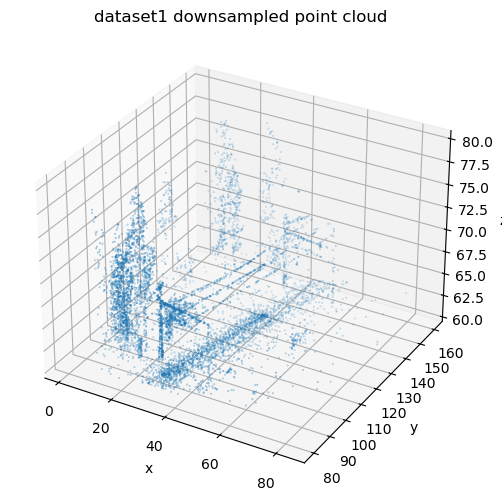

In [20]:
# show downsampled data
%matplotlib inline
show_cloud(pcd[::10], title='dataset1 downsampled point cloud') # keep every 10th point

## Task 1 (3)

Find the best value for the ground level.  
One way to do it is using a histogram: `np.histogram`.

Update the function `get_ground_level()` with your changes.

For both the datasets:

- Report the ground level in the readme file in your github project.
- Add the histogram plots to your project readme.

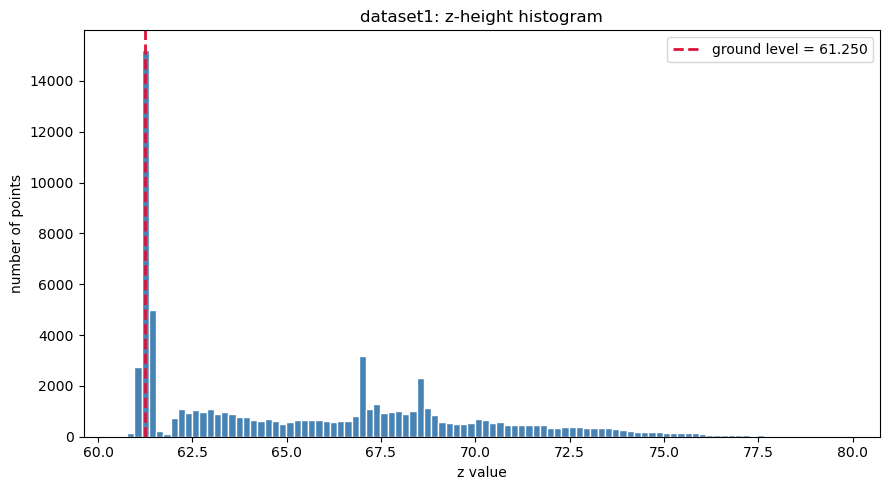

dataset1: ground level = 61.250


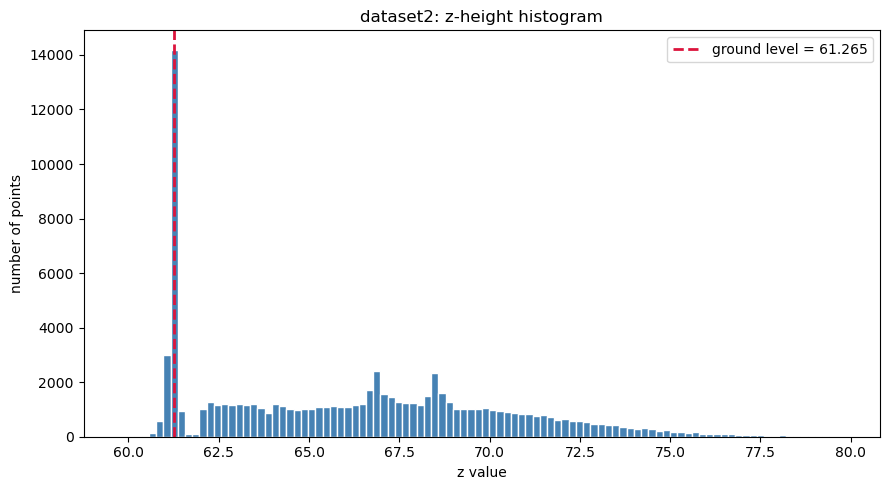

dataset2: ground level = 61.265


In [21]:
# Task 1: estimate ground level for both datasets using z-height histograms.
ground_levels = {}
pcd_above_ground_by_dataset = {}

for dataset_name, data in datasets.items():
    ground_level = plot_ground_histogram(data, dataset_name, bins=100)
    ground_levels[dataset_name] = ground_level
    pcd_above_ground_by_dataset[dataset_name] = data[data[:, 2] > ground_level]
    print(f'{dataset_name}: ground level = {ground_level:.3f}')

# Keep dataset1 selected for the starter cells below.
est_ground_level = ground_levels['dataset1']
pcd_above_ground = pcd_above_ground_by_dataset['dataset1']

In [22]:
{name: points.shape for name, points in pcd_above_ground_by_dataset.items()}

{'dataset1': (62411, 3), 'dataset2': (71858, 3)}

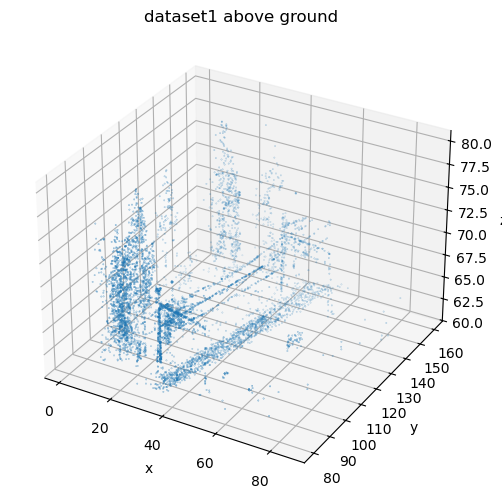

In [23]:
# side view
show_cloud(pcd_above_ground[::10], title='dataset1 above ground')

In [24]:
# The original starter code used eps = 10 here.
# Task 2 below estimates eps from k-distance elbow plots instead.

In [25]:
# See the Task 2 section below for the optimized DBSCAN run.

In [26]:
# See the Task 2 section below for cluster plots.

## Task 2 (+1)

Find an optimized value for `eps`.

Plot the elbow and extract the optimal value from the plot. Apply DBSCAN again with the new eps value and confirm visually that clusters are proper.

Useful links:

- https://www.analyticsvidhya.com/blog/2020/09/how-dbscan-clustering-works/
- https://machinelearningknowledge.ai/tutorial-for-dbscan-clustering-in-python-sklearn/

For both the datasets:

- Report the optimal value of eps in the Readme to your github project.
- Add the elbow plots to your github project Readme.
- Add the cluster plots to your github project Readme.

In [27]:
def plot_eps_elbow(points, dataset_name, selected_eps, min_samples=5):
    tree = KDTree(points)
    distances, _ = tree.query(points, k=min_samples)
    k_distances = np.sort(distances[:, -1])

    Path('images').mkdir(exist_ok=True)
    eps_idx = np.searchsorted(k_distances, selected_eps)
    eps_idx = min(eps_idx, len(k_distances) - 1)

    plt.figure(figsize=(9, 5))
    plt.plot(k_distances, linewidth=1.5)
    plt.axhline(selected_eps, color='crimson', linestyle='--', linewidth=2, label=f'selected eps = {selected_eps:.3f}')
    plt.scatter(eps_idx, k_distances[eps_idx], color='crimson', s=45)
    plt.title(f'{dataset_name}: DBSCAN k-distance elbow plot')
    plt.xlabel('points sorted by distance')
    plt.ylabel(f'distance to {min_samples}th nearest neighbor')
    plt.legend()
    plt.tight_layout()
    plt.savefig(Path('images') / f'{dataset_name}_dbscan_elbow.png', dpi=200)
    plt.show()

    return k_distances

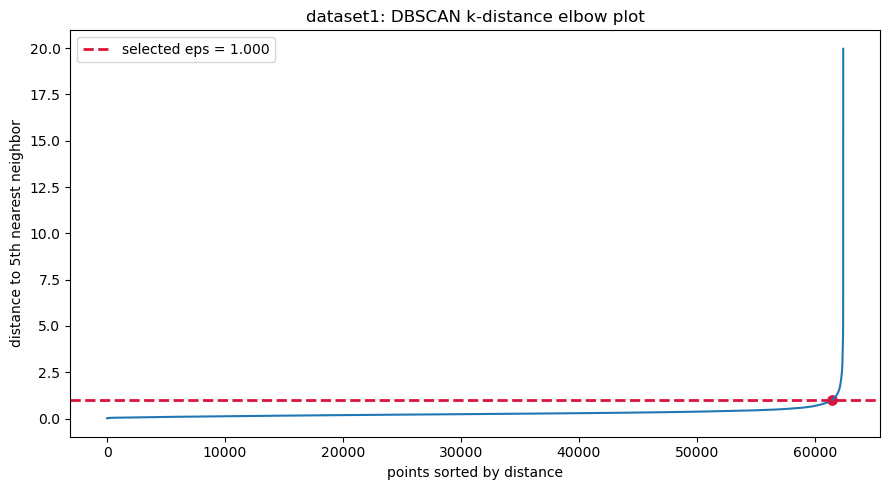

dataset1: selected eps = 1.000


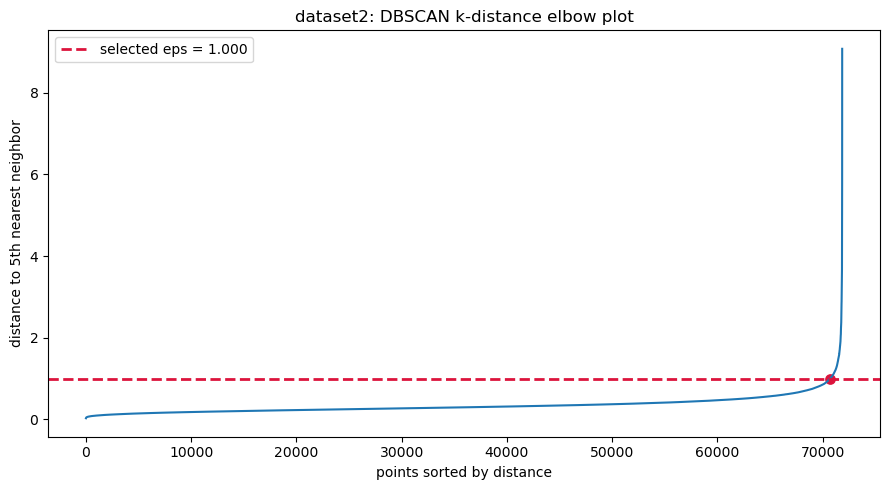

dataset2: selected eps = 1.000


{'dataset1': 1.0, 'dataset2': 1.0}

In [28]:
min_samples = 5

# Chosen from the elbow plots: this is near the beginning of the sharp upward bend.
eps_values = {
    'dataset1': 1.0,
    'dataset2': 1.0,
}

k_distances_by_dataset = {}

for dataset_name, points in pcd_above_ground_by_dataset.items():
    k_distances = plot_eps_elbow(points, dataset_name, selected_eps=eps_values[dataset_name], min_samples=min_samples)
    k_distances_by_dataset[dataset_name] = k_distances
    print(f'{dataset_name}: selected eps = {eps_values[dataset_name]:.3f}')

eps_values

In [29]:
def plot_dbscan_clusters(points, labels, dataset_name, eps):
    clusters = len(set(labels)) - (1 if -1 in labels else 0)

    Path('images').mkdir(exist_ok=True)

    plt.figure(figsize=(8, 8))
    plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='tab20', s=2)
    plt.title(f'{dataset_name}: DBSCAN clusters, eps={eps:.3f}, clusters={clusters}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(Path('images') / f'{dataset_name}_dbscan_clusters.png', dpi=200)
    plt.show()

    return clusters

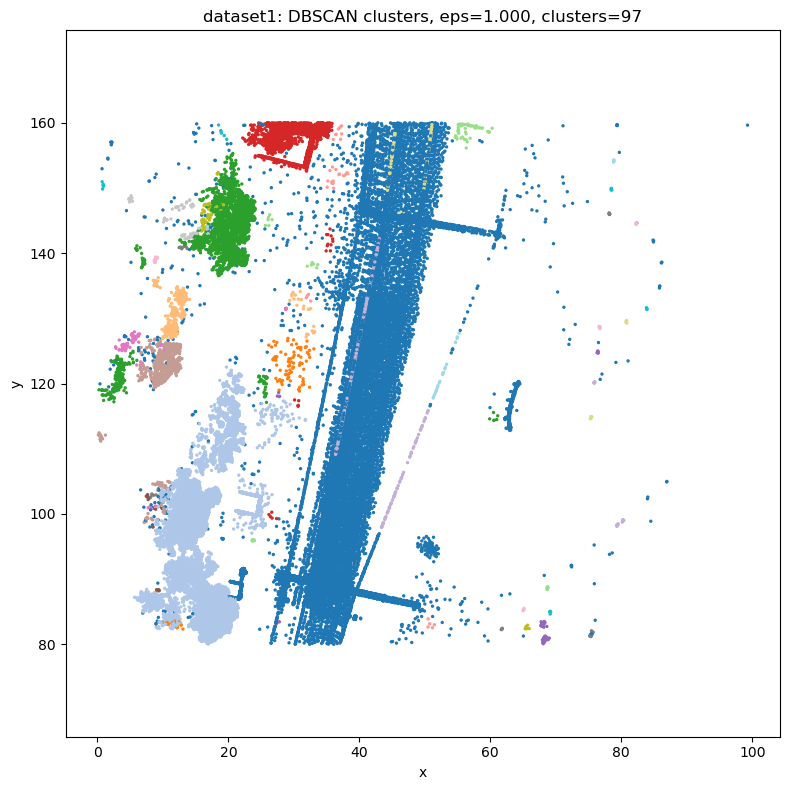

dataset1: eps = 1.000, clusters = 97, noise points = 618


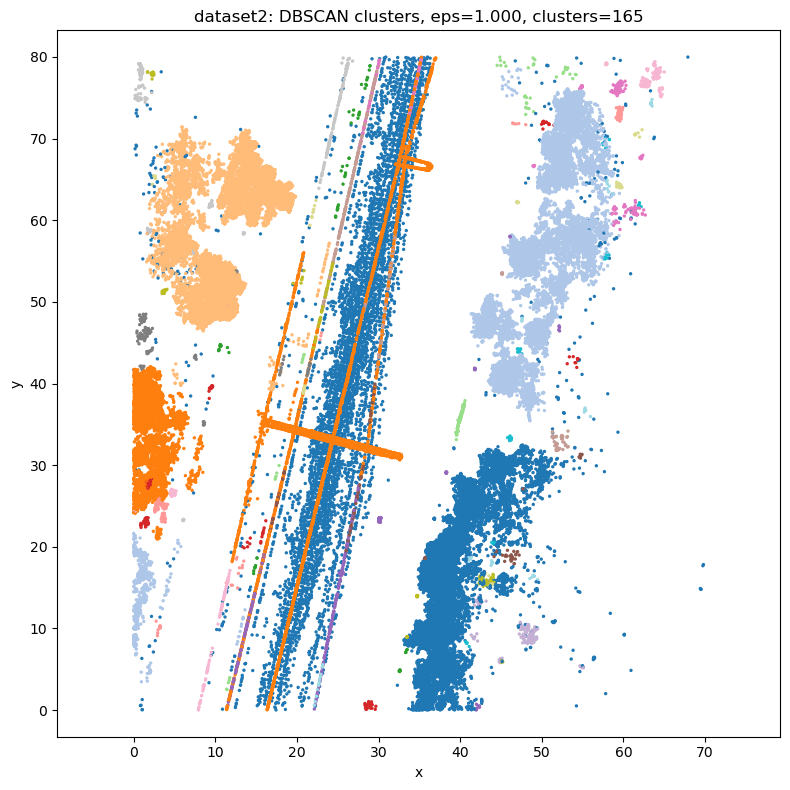

dataset2: eps = 1.000, clusters = 165, noise points = 612


In [30]:
dbscan_results = {}
cluster_counts = {}

for dataset_name, points in pcd_above_ground_by_dataset.items():
    eps = eps_values[dataset_name]
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
    labels = clustering.labels_
    dbscan_results[dataset_name] = clustering
    cluster_counts[dataset_name] = plot_dbscan_clusters(points, labels, dataset_name, eps)
    noise_points = np.sum(labels == -1)
    print(f'{dataset_name}: eps = {eps:.3f}, clusters = {cluster_counts[dataset_name]}, noise points = {noise_points}')

## Task 3 (+1)

Find the largest cluster, since that should be the catenary. Beware of the noise cluster.

Use the x,y span for the clusters to find the largest cluster.

For both the datasets:

- Report `min(x)`, `min(y)`, `max(x)`, `max(y)` for the catenary cluster in the Readme of your github project.
- Add the plot of the catenary cluster to the readme.